This notebook explores the Maximum Resale Price of housing units using the merged dataset of resale properties and prices, focusing on various features such as documentation type, age restrictions, town, and number of bedrooms.
We’ll visualize trends, distributions, and relationships between these variables to uncover meaningful insights.We begin by loading the dataset and examining its structure to understand available columns and the type of data we’ll be analyzing.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("/content/merged_dataset_price&resale_Sept25.csv")

# Inspect the first few rows
print(df.head())




      Town               Address Unit Number Maximum Resale Price  \
0  Andover  170 Haverhill Street         117         $227,298.00    
1  Andover  174 Haverhill Street         313                  NaN   
2  Andover  600L Brookside Drive        600L                  NaN   
3     Ayer   16B Longview Circle          68                  NaN   
4     Ayer     18A Longview Cir.          54                  NaN   

  Property Feature           Development Transaction Start Date Closing Date  \
0              NaN      Coachman's Ridge                 1/8/24      4/30/24   
1              NaN      Coachman's Ridge               10/13/21      1/21/22   
2              NaN  Brookside at Andover               12/12/21      3/21/22   
3              NaN           The Willows                4/25/23       7/7/23   
4              NaN           The Willows                 3/7/25      5/16/25   

   Bedrooms Age Restricted  ... Duplicate Unique ID        Street Address  \
0       1.0             No 

In [2]:
print(df.columns.tolist())

['Town', 'Address', 'Unit Number', 'Maximum Resale Price', 'Property Feature', 'Development', 'Transaction Start Date', 'Closing Date', 'Bedrooms', 'Age Restricted', 'Full/Lite Documentation', 'Duplicate', 'Unique ID', 'Street Address', 'City', 'State', 'ZIP', 'Match Status', 'Match Type', 'Matched Address', 'MSA']


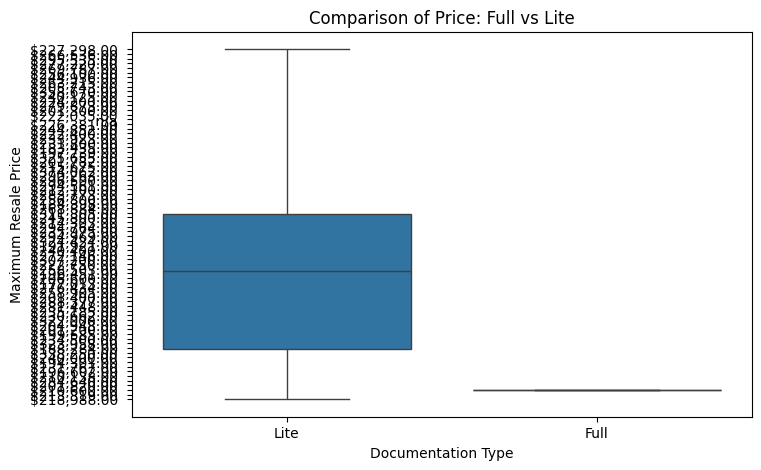

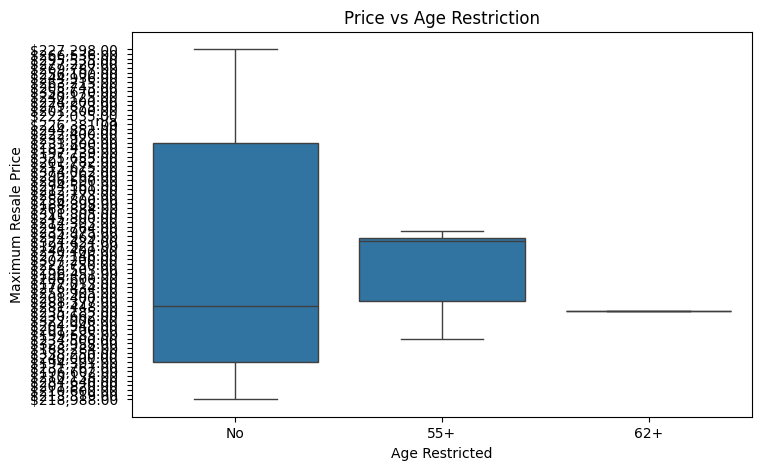

/tmp/ipython-input-1638826236.py:24: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x="Town", y="Maximum Resale Price", estimator='mean', ci=None)


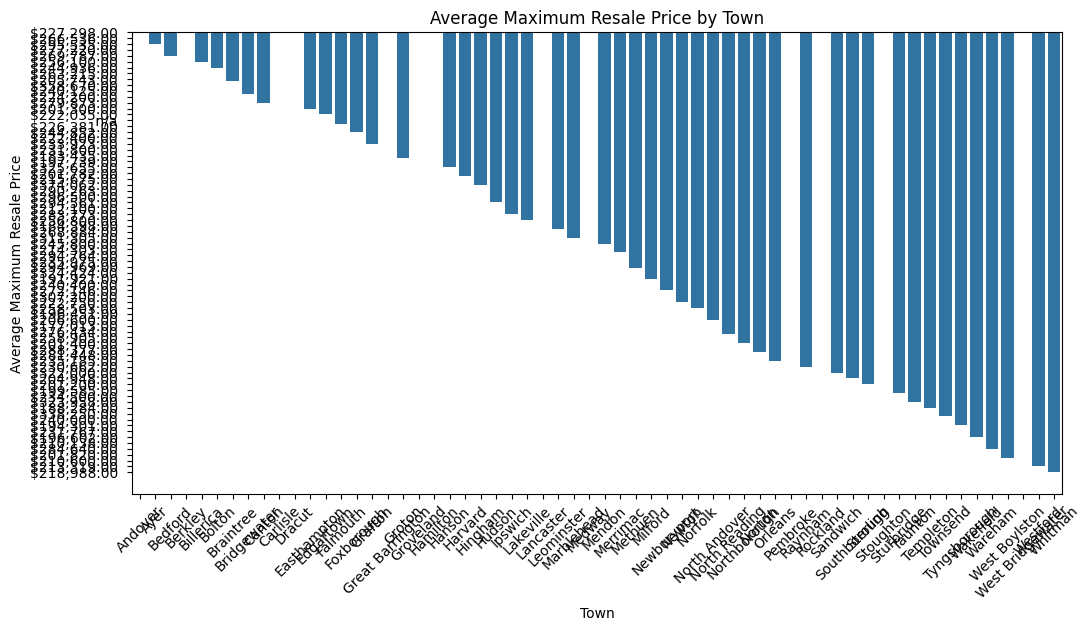

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# --- Visualization 1: Price Comparison between Full and Lite ---
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Full/Lite Documentation", y="Maximum Resale Price")
plt.title("Comparison of Price: Full vs Lite")
plt.xlabel("Documentation Type")
plt.ylabel("Maximum Resale Price")
plt.show()

# --- Visualization 2: Price vs Age Restricted ---
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Age Restricted", y="Maximum Resale Price")
plt.title("Price vs Age Restriction")
plt.xlabel("Age Restricted")
plt.ylabel("Maximum Resale Price")
plt.show()

# --- Visualization 3: Price vs Town ---
plt.figure(figsize=(12,6))
sns.barplot(data=df, x="Town", y="Maximum Resale Price", estimator='mean', ci=None)
plt.xticks(rotation=45)
plt.title("Average Maximum Resale Price by Town")
plt.xlabel("Town")
plt.ylabel("Average Maximum Resale Price")
plt.show()


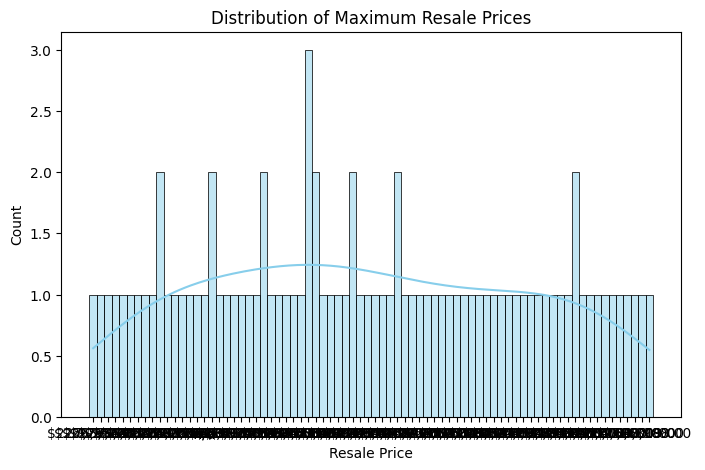

/tmp/ipython-input-3414850328.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Full/Lite Documentation", y="Maximum Resale Price", palette="pastel")


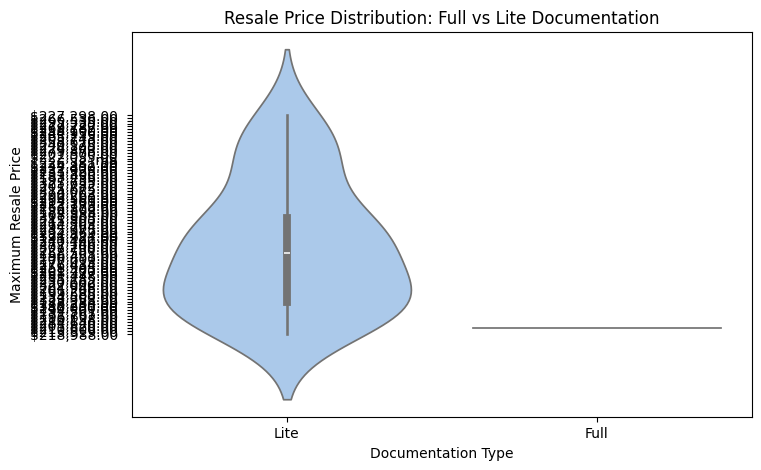

/tmp/ipython-input-3414850328.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Age Restricted", y="Maximum Resale Price", palette="Set2")


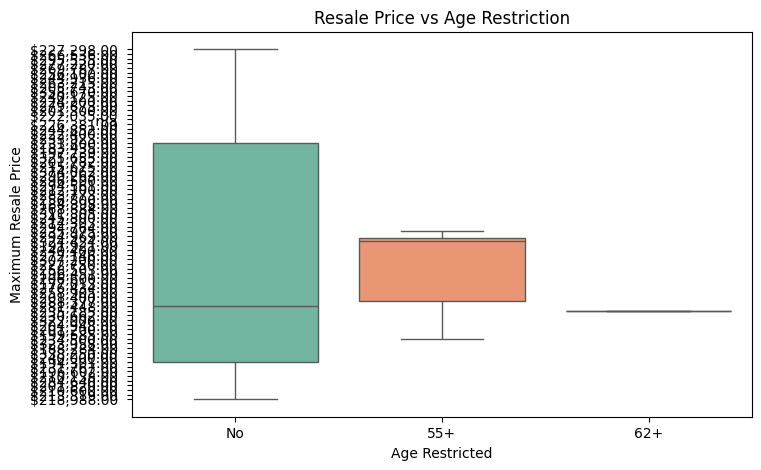

TypeError: agg function failed [how->mean,dtype->object]

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns




# --- Visualization 1: Distribution of resale prices ---
plt.figure(figsize=(8,5))
sns.histplot(df["Maximum Resale Price"], bins=30, kde=True, color='skyblue')
plt.title("Distribution of Maximum Resale Prices")
plt.xlabel("Resale Price")
plt.ylabel("Count")
plt.show()

# --- Visualization 2: Price distribution by Full vs Lite ---
plt.figure(figsize=(8,5))
sns.violinplot(data=df, x="Full/Lite Documentation", y="Maximum Resale Price", palette="pastel")
plt.title("Resale Price Distribution: Full vs Lite Documentation")
plt.xlabel("Documentation Type")
plt.ylabel("Maximum Resale Price")
plt.show()

# --- Visualization 3: Price vs Age Restricted ---
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Age Restricted", y="Maximum Resale Price", palette="Set2")
plt.title("Resale Price vs Age Restriction")
plt.xlabel("Age Restricted")
plt.ylabel("Maximum Resale Price")
plt.show()

# --- Visualization 4: Top 10 towns by average price ---
top_towns = (
    df.groupby("Town")["Maximum Resale Price"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10,6))
sns.barplot(data=top_towns, x="Town", y="Maximum Resale Price", palette="viridis")
plt.title("Top 10 Towns by Average Maximum Resale Price")
plt.xlabel("Town")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.show()

# --- (Optional) Visualization 5: Price vs Bedrooms, colored by Full/Lite ---
if "Bedrooms" in df.columns:
    plt.figure(figsize=(8,5))
    sns.scatterplot(
        data=df,
        x="Bedrooms",
        y="Maximum Resale Price",
        hue="Full/Lite Documentation",
        alpha=0.7
    )
    plt.title("Price vs Bedrooms by Documentation Type")
    plt.xlabel("Number of Bedrooms")
    plt.ylabel("Maximum Resale Price")
    plt.show()


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset

# Clean up and convert price column
df["Maximum Resale Price"] = (
    df["Maximum Resale Price"]
    .replace('[\$,]', '', regex=True)  # remove $ and commas
    .replace('', pd.NA)                # replace empty strings with NaN
)

# Convert to numeric safely
df["Maximum Resale Price"] = pd.to_numeric(df["Maximum Resale Price"], errors='coerce')

# Drop rows with missing or invalid prices
df = df.dropna(subset=["Maximum Resale Price"])






<>:10: SyntaxWarning: invalid escape sequence '\$'
<>:10: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipython-input-1946217302.py:10: SyntaxWarning: invalid escape sequence '\$'
  .replace('[\$,]', '', regex=True)  # remove $ and commas


/tmp/ipython-input-1551213488.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


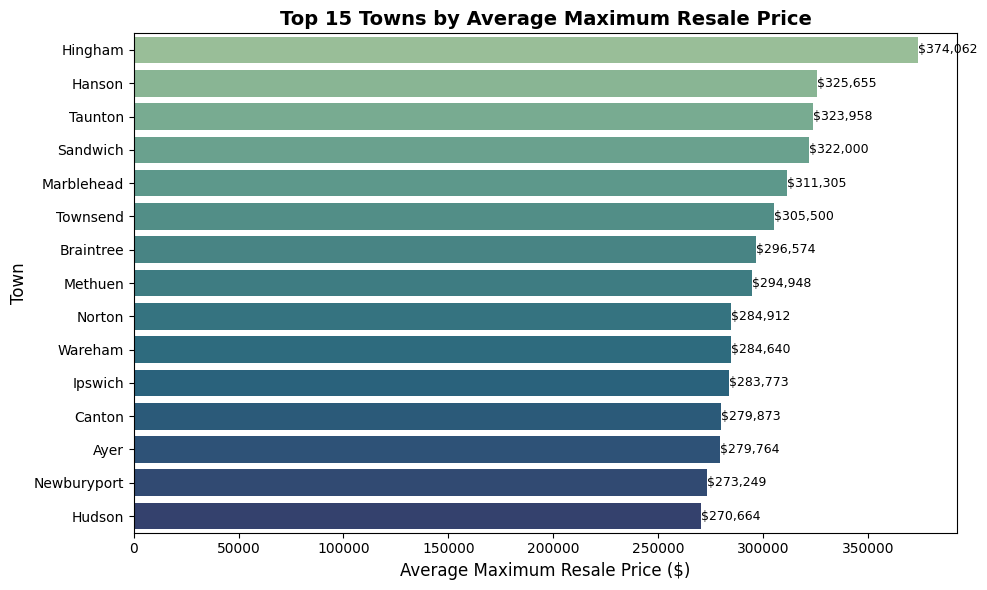

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# Calculate average price by town and select top 15
top_towns = (
    df.groupby("Town")["Maximum Resale Price"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)

# --- Improved Visualization: Horizontal bar chart ---
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_towns,
    y="Town",
    x="Maximum Resale Price",
    palette="crest"
)

# Add titles and labels
plt.title("Top 15 Towns by Average Maximum Resale Price", fontsize=14, fontweight='bold')
plt.xlabel("Average Maximum Resale Price ($)", fontsize=12)
plt.ylabel("Town", fontsize=12)

# Add formatted value labels
for index, value in enumerate(top_towns["Maximum Resale Price"]):
    plt.text(value, index, f"${value:,.0f}", va='center', ha='left', fontsize=9)

plt.tight_layout()
plt.show()


<>:9: SyntaxWarning: invalid escape sequence '\$'
<>:9: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipython-input-195205069.py:9: SyntaxWarning: invalid escape sequence '\$'
  .replace('[\$,]', '', regex=True)


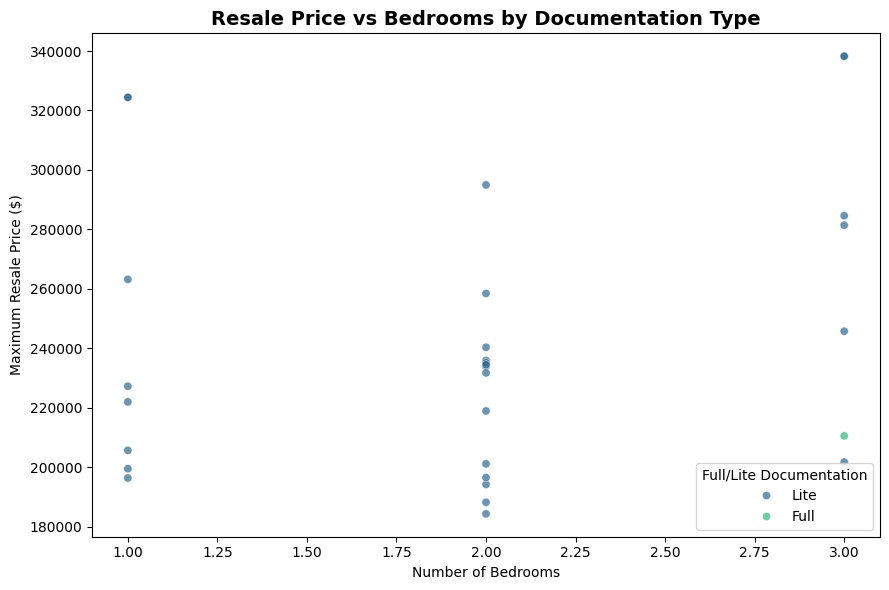

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Clean price column
df["Maximum Resale Price"] = (
    df["Maximum Resale Price"]
    .replace('[\$,]', '', regex=True)
    .replace('', pd.NA)
)
df["Maximum Resale Price"] = pd.to_numeric(df["Maximum Resale Price"], errors='coerce')

plt.figure(figsize=(9,6))
sns.scatterplot(
    data=df,
    x="Bedrooms",
    y="Maximum Resale Price",
    hue="Full/Lite Documentation",
    alpha=0.7,
    palette="viridis"
)
plt.title("Resale Price vs Bedrooms by Documentation Type", fontsize=14, fontweight='bold')
plt.xlabel("Number of Bedrooms")
plt.ylabel("Maximum Resale Price ($)")
plt.tight_layout()
plt.show()


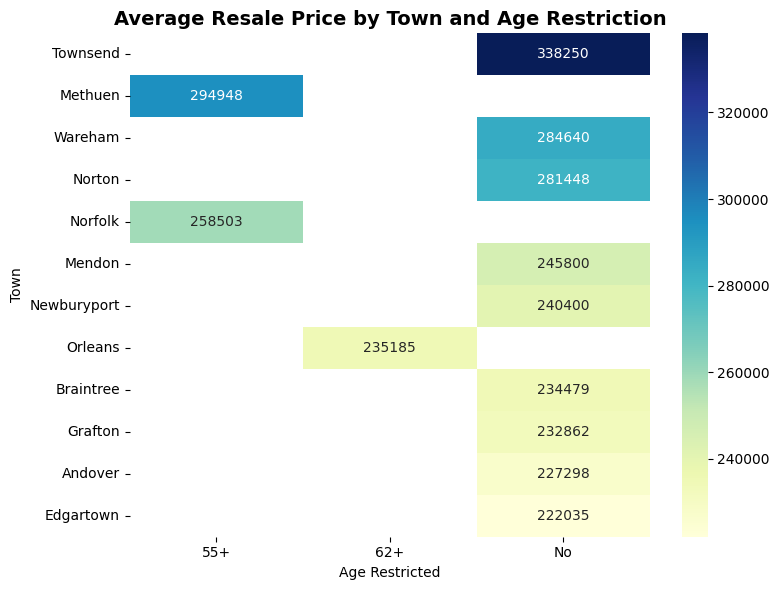

In [ ]:
pivot = (
    df.pivot_table(
        index="Town",
        columns="Age Restricted",
        values="Maximum Resale Price",
        aggfunc="mean"
    )
)

# Keep only top 12 towns for readability
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).head(12).index]

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Average Resale Price by Town and Age Restriction", fontsize=14, fontweight='bold')
plt.xlabel("Age Restricted")
plt.ylabel("Town")
plt.tight_layout()
plt.show()


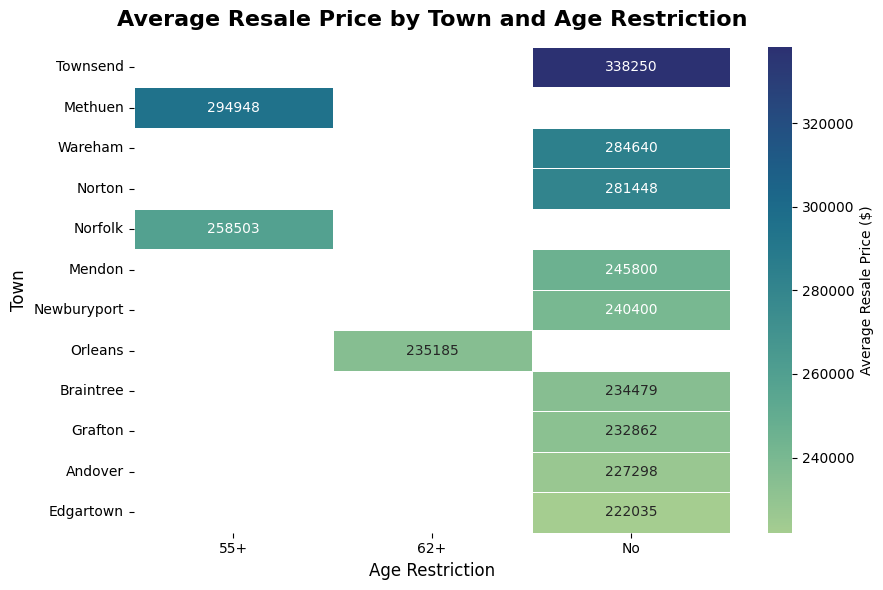

In [ ]:
plt.figure(figsize=(9,6))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap="crest",
    linewidths=0.5,
    cbar_kws={'label': 'Average Resale Price ($)'}
)

plt.title("Average Resale Price by Town and Age Restriction", fontsize=16, fontweight='bold', pad=15)
plt.xlabel("Age Restriction", fontsize=12)
plt.ylabel("Town", fontsize=12)

# Improve overall layout and readability
plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()


/tmp/ipython-input-1026870809.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


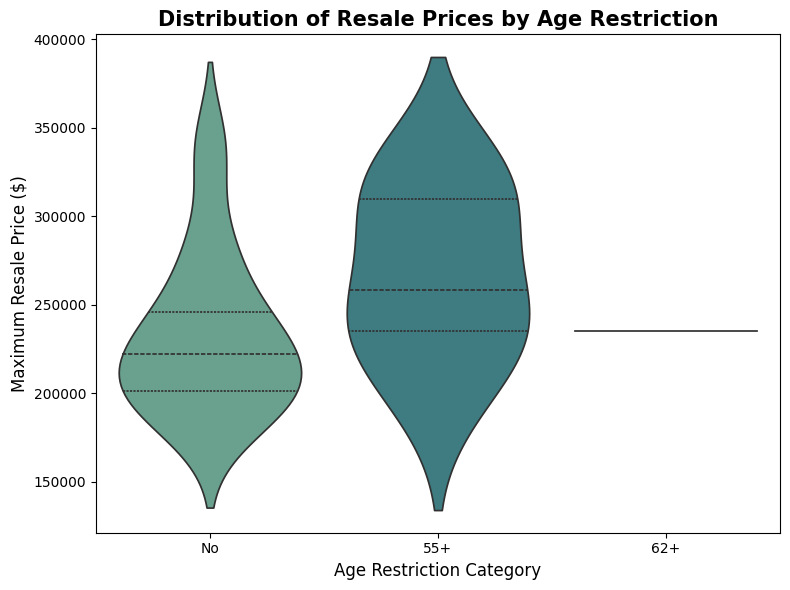

/tmp/ipython-input-1026870809.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


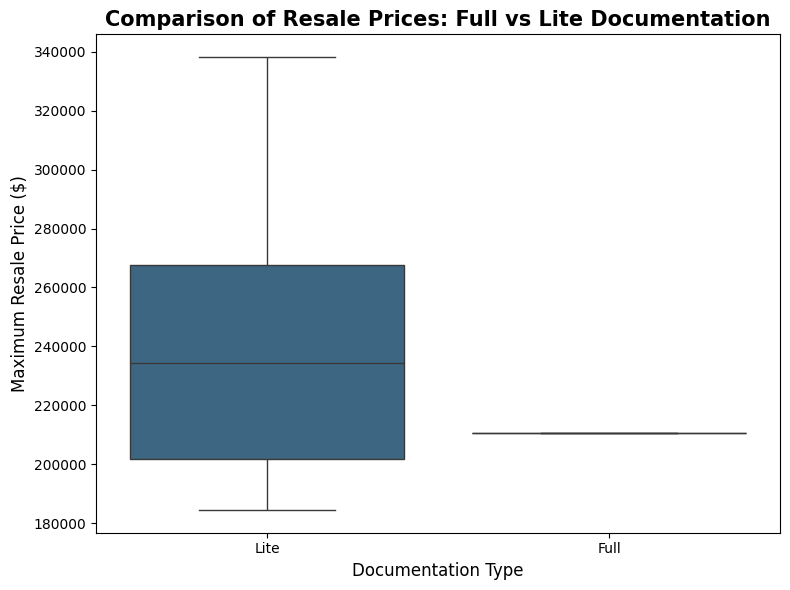

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



df["Maximum Resale Price"] = pd.to_numeric(df["Maximum Resale Price"], errors='coerce')
df = df.dropna(subset=["Maximum Resale Price"])

# --- Visualization 1: Price vs Age Restricted ---
plt.figure(figsize=(8,6))
sns.violinplot(
    data=df,
    x="Age Restricted",
    y="Maximum Resale Price",
    palette="crest",
    inner="quartile"
)
plt.title("Distribution of Resale Prices by Age Restriction", fontsize=15, fontweight='bold')
plt.xlabel("Age Restriction Category", fontsize=12)
plt.ylabel("Maximum Resale Price ($)", fontsize=12)
plt.tight_layout()
plt.show()

# --- Visualization 2: Price vs Full/Lite Documentation ---
plt.figure(figsize=(8,6))
sns.boxplot(
    data=df,
    x="Full/Lite Documentation",
    y="Maximum Resale Price",
    palette="viridis"
)
plt.title("Comparison of Resale Prices: Full vs Lite Documentation", fontsize=15, fontweight='bold')
plt.xlabel("Documentation Type", fontsize=12)
plt.ylabel("Maximum Resale Price ($)", fontsize=12)
plt.tight_layout()
plt.show()


/tmp/ipython-input-3677087036.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


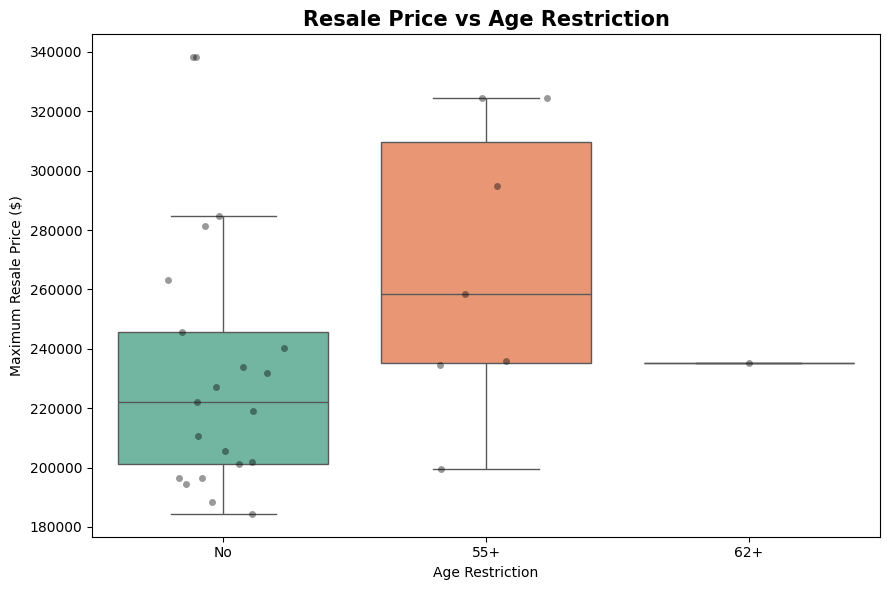

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df["Maximum Resale Price"] = pd.to_numeric(df["Maximum Resale Price"], errors="coerce")

plt.figure(figsize=(9,6))
sns.boxplot(
    data=df, x="Age Restricted", y="Maximum Resale Price",
    palette="Set2", showfliers=False
)
sns.stripplot(
    data=df, x="Age Restricted", y="Maximum Resale Price",
    color="black", alpha=0.4, jitter=0.25
)
plt.title("Resale Price vs Age Restriction", fontsize=15, fontweight="bold")
plt.xlabel("Age Restriction")
plt.ylabel("Maximum Resale Price ($)")
plt.tight_layout()
plt.show()


/tmp/ipython-input-1052420069.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(


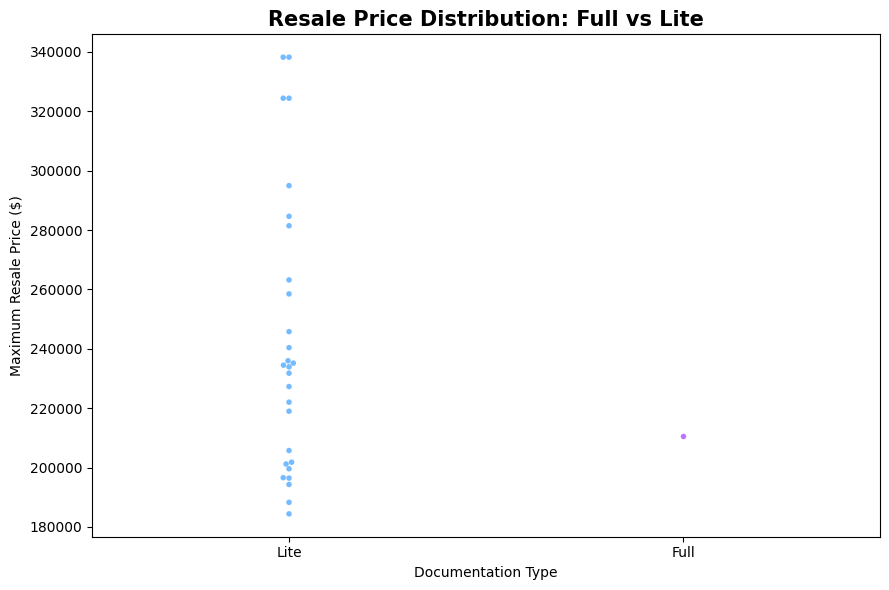

In [ ]:
plt.figure(figsize=(9,6))
sns.swarmplot(
    data=df,
    x="Full/Lite Documentation",
    y="Maximum Resale Price",
    palette="cool",
    size=4,
    alpha=0.8
)
plt.title("Resale Price Distribution: Full vs Lite", fontsize=15, fontweight="bold")
plt.xlabel("Documentation Type")
plt.ylabel("Maximum Resale Price ($)")
plt.tight_layout()
plt.show()


/tmp/ipython-input-1212401821.py:2: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


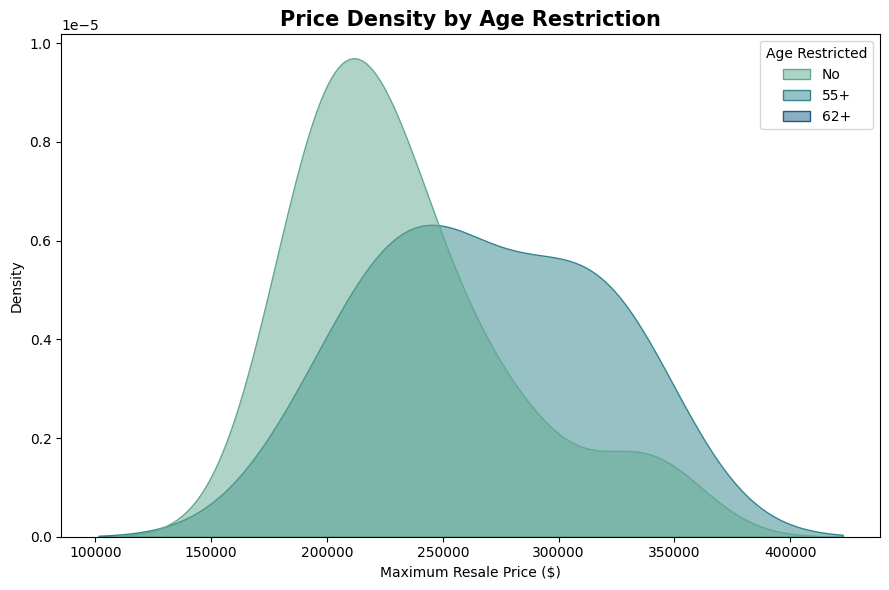

In [ ]:
plt.figure(figsize=(9,6))
sns.kdeplot(
    data=df, x="Maximum Resale Price",
    hue="Age Restricted",
    fill=True, common_norm=False, alpha=0.5, palette="crest"
)
plt.title("Price Density by Age Restriction", fontsize=15, fontweight="bold")
plt.xlabel("Maximum Resale Price ($)")
plt.ylabel("Density")
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Ensure price column is numeric
df['Maximum Resale Price'] = pd.to_numeric(df['Maximum Resale Price'], errors='coerce')

# Filter for the selected towns
selected_towns = ['Medway', 'North Andover', 'Canton', 'Billerica', 'Rockland']
filtered_df = df[df['Town'].isin(selected_towns)]

# Get the high


/tmp/ipython-input-2725942913.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


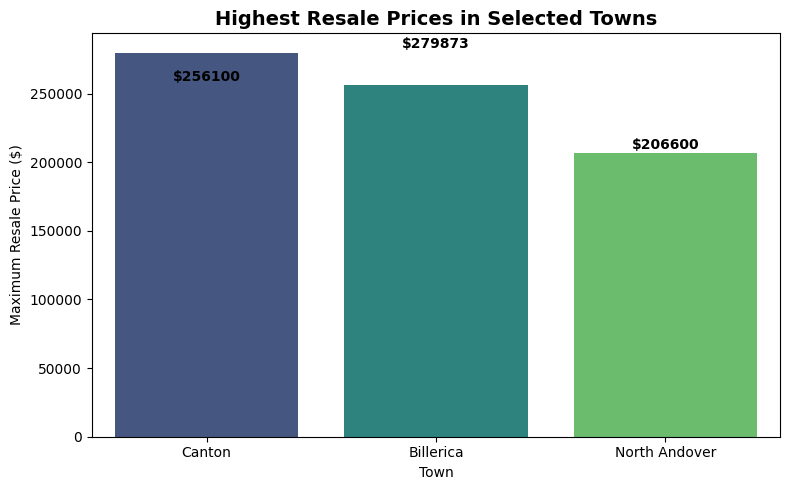

In [ ]:
top_prices = filtered_df.groupby('Town')['Maximum Resale Price'].max().reset_index()

# Sort by price descending
top_prices = top_prices.sort_values(by='Maximum Resale Price', ascending=False)

# Visualization
plt.figure(figsize=(8,5))
sns.barplot(
    data=top_prices,
    x='Town',
    y='Maximum Resale Price',
    palette='viridis'
)

# Add value labels
for index, row in top_prices.iterrows():
    plt.text(index, row['Maximum Resale Price'] + 1000, f"${row['Maximum Resale Price']:.0f}",
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title("Highest Resale Prices in Selected Towns", fontsize=14, fontweight='bold')
plt.xlabel("Town")
plt.ylabel("Maximum Resale Price ($)")
plt.tight_layout()
plt.show()

/tmp/ipython-input-2504141967.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=selected_towns, x='Town', y='Maximum Resale Price', palette='coolwarm')
/tmp/ipython-input-2504141967.py:41: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


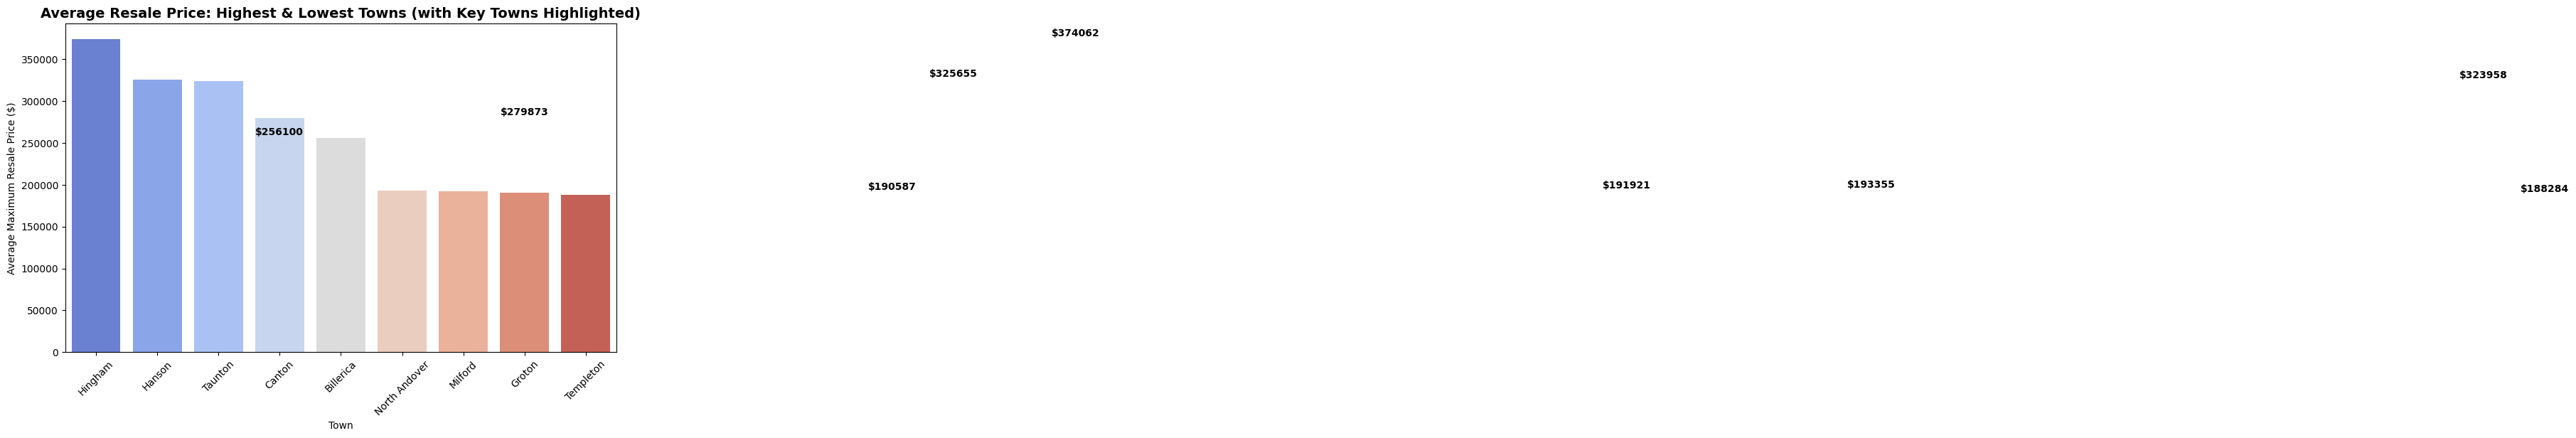

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



# Ensure price column is numeric
df['Maximum Resale Price'] = pd.to_numeric(df['Maximum Resale Price'], errors='coerce')

# Compute average price per town
avg_price = df.groupby('Town')['Maximum Resale Price'].mean().reset_index()

# Identify top 3 and bottom 3 towns
top3 = avg_price.nlargest(3, 'Maximum Resale Price')
bottom3 = avg_price.nsmallest(3, 'Maximum Resale Price')

# Ensure key towns are included
key_towns = ['Medway', 'North Andover', 'Canton', 'Billerica', 'Rockland']
key_data = avg_price[avg_price['Town'].isin(key_towns)]

# Combine all selected towns (unique only)
selected_towns = pd.concat([top3, bottom3, key_data]).drop_duplicates('Town')

# Sort by price for better visuals
selected_towns = selected_towns.sort_values('Maximum Resale Price', ascending=False)

# Visualization
plt.figure(figsize=(10,6))
sns.barplot(data=selected_towns, x='Town', y='Maximum Resale Price', palette='coolwarm')

# Add price labels
for index, row in selected_towns.iterrows():
    plt.text(index, row['Maximum Resale Price'] + 1000, f"${row['Maximum Resale Price']:.0f}",
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title("Average Resale Price: Highest & Lowest Towns (with Key Towns Highlighted)",
          fontsize=14, fontweight='bold')
plt.xlabel("Town")
plt.ylabel("Average Maximum Resale Price ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


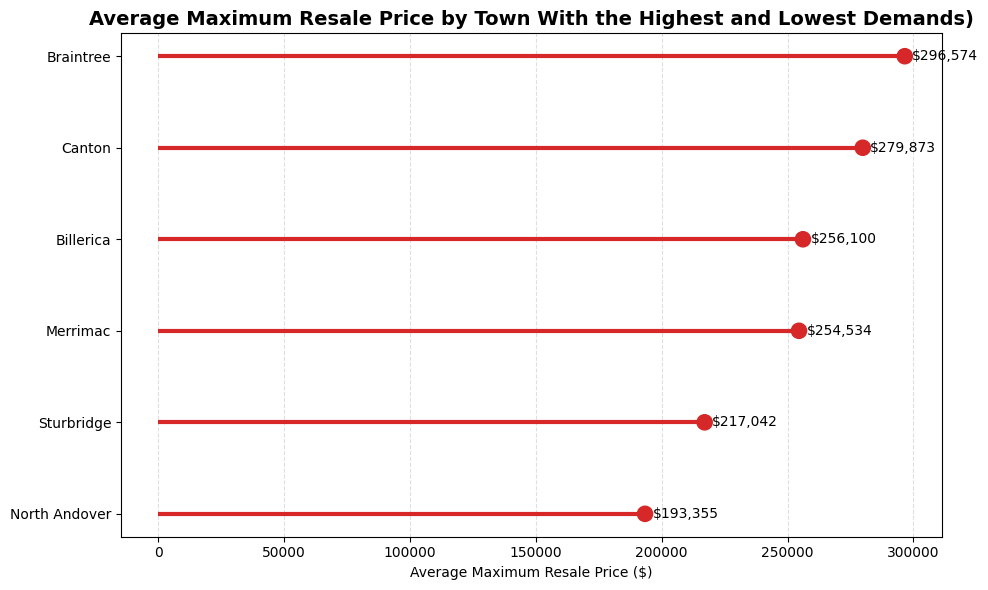

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


# Ensure numeric price
df['Maximum Resale Price'] = pd.to_numeric(df['Maximum Resale Price'], errors='coerce')

# Average price by town
avg_price = df.groupby('Town', as_index=False)['Maximum Resale Price'].mean()

# Select top 3 and bottom 3
top3 = avg_price.nlargest(3, 'Maximum Resale Price')
bottom3 = avg_price.nsmallest(3, 'Maximum Resale Price')

# Add focus towns
key_towns = ['Medway', 'North Andover', 'Canton', 'Billerica', 'Rockland','Merrimac','Lancaster','Sturbridge','Braintree']
key_data = avg_price[avg_price['Town'].isin(key_towns)]

# Combine and remove duplicates
selected = pd.concat([key_data]).drop_duplicates('Town')
selected = selected.sort_values('Maximum Resale Price', ascending=True)

# Highlight key towns
selected['color'] = selected['Town'].apply(lambda x: '#d62828' if x in key_towns else '#457b9d')

# Plot (Lollipop chart)
plt.figure(figsize=(10,6))
plt.hlines(y=selected['Town'], xmin=0, xmax=selected['Maximum Resale Price'],
           color=selected['color'], linewidth=3)
plt.scatter(selected['Maximum Resale Price'], selected['Town'],
            color=selected['color'], s=120)

# Labels
for i, (town, price) in enumerate(zip(selected['Town'], selected['Maximum Resale Price'])):
    plt.text(price + 3000, town, f"${price:,.0f}", va='center', fontsize=10)

# Style
plt.title("Average Maximum Resale Price by Town With the Highest and Lowest Demands)",
          fontsize=14, fontweight='bold')
plt.xlabel("Average Maximum Resale Price ($)")
plt.ylabel("")
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


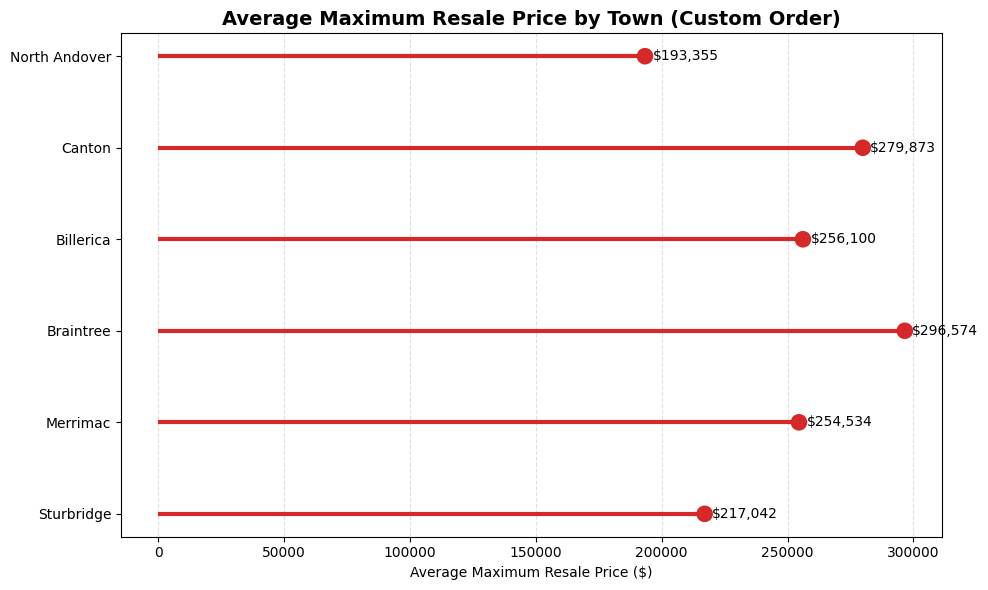

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure numeric price
df['Maximum Resale Price'] = pd.to_numeric(df['Maximum Resale Price'], errors='coerce')

# Average price by town
avg_price = df.groupby('Town', as_index=False)['Maximum Resale Price'].mean()

# Select top 3 and bottom 3
top3 = avg_price.nlargest(3, 'Maximum Resale Price')
bottom3 = avg_price.nsmallest(3, 'Maximum Resale Price')

# Add focus towns
key_towns = ['Medway', 'North Andover', 'Canton', 'Billerica', 'Rockland',
             'Merrimac', 'Lancaster', 'Sturbridge', 'Braintree']
key_data = avg_price[avg_price['Town'].isin(key_towns)]

# Combine and remove duplicates
selected = pd.concat([key_data]).drop_duplicates('Town')

# ✅ Define custom order (you can rearrange this list as you like)
custom_order = ['Sturbridge', 'Lancaster', 'Merrimac', 'Braintree',
 'Billerica', 'Canton', 'North Andover', 'Medway']


# Apply the custom order
selected['Town'] = pd.Categorical(selected['Town'], categories=custom_order, ordered=True)
selected = selected.sort_values('Town')

# Highlight key towns
selected['color'] = selected['Town'].apply(lambda x: '#d62828' if x in key_towns else '#457b9d')

# Plot (Lollipop chart)
plt.figure(figsize=(10,6))
plt.hlines(y=selected['Town'], xmin=0, xmax=selected['Maximum Resale Price'],
           color=selected['color'], linewidth=3)
plt.scatter(selected['Maximum Resale Price'], selected['Town'],
            color=selected['color'], s=120)

# Labels
for i, (town, price) in enumerate(zip(selected['Town'], selected['Maximum Resale Price'])):
    plt.text(price + 3000, town, f"${price:,.0f}", va='center', fontsize=10)

# Style
plt.title("Average Maximum Resale Price by Town (Custom Order)",
          fontsize=14, fontweight='bold')
plt.xlabel("Average Maximum Resale Price ($)")
plt.ylabel("")
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


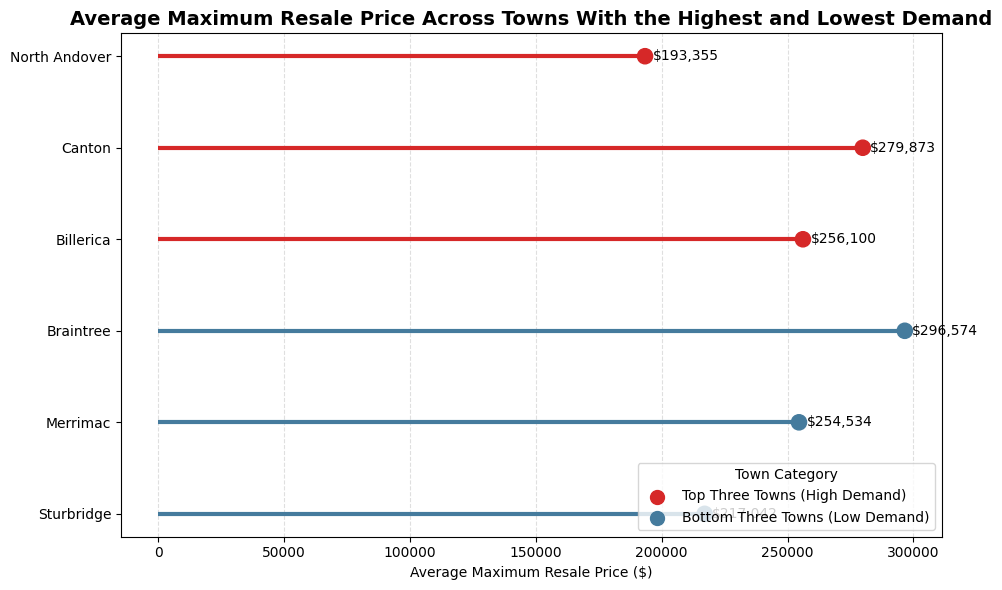

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure numeric price
df['Maximum Resale Price'] = pd.to_numeric(df['Maximum Resale Price'], errors='coerce')

# Average price by town
avg_price = df.groupby('Town', as_index=False)['Maximum Resale Price'].mean()

# Add focus towns
key_towns = ['Medway', 'North Andover', 'Canton', 'Billerica',
             'Braintree', 'Merrimac', 'Lancaster', 'Sturbridge']
key_data = avg_price[avg_price['Town'].isin(key_towns)]

# Combine and remove duplicates
selected = pd.concat([key_data]).drop_duplicates('Town')

# ✅ Custom reversed order
custom_order = ['Sturbridge', 'Lancaster', 'Merrimac', 'Braintree',
                'Billerica', 'Canton', 'North Andover', 'Medway']

# Apply the custom order
selected['Town'] = pd.Categorical(selected['Town'], categories=custom_order, ordered=True)
selected = selected.sort_values('Town')

# ✅ Color rule: first 3 = blue (bottom 3 demand), rest = red (top 3 demand)
selected['color'] = ['#457b9d' if i < 3 else '#d62828' for i in range(len(selected))]

# Plot (Lollipop chart)
plt.figure(figsize=(10,6))
plt.hlines(y=selected['Town'], xmin=0, xmax=selected['Maximum Resale Price'],
           color=selected['color'], linewidth=3)
plt.scatter(selected['Maximum Resale Price'], selected['Town'],
            color=selected['color'], s=120)

# Labels
for i, (town, price) in enumerate(zip(selected['Town'], selected['Maximum Resale Price'])):
    plt.text(price + 3000, town, f"${price:,.0f}", va='center', fontsize=10)

# Title & labels
plt.title("Average Maximum Resale Price Across Towns With the Highest and Lowest Demand",
          fontsize=14, fontweight='bold')
plt.xlabel("Average Maximum Resale Price ($)")
plt.ylabel("")

# ✅ Legend
plt.scatter([], [], color='#d62828', label='Top Three Towns (High Demand)', s=100)
plt.scatter([], [], color='#457b9d', label='Bottom Three Towns (Low Demand)', s=100)
plt.legend(title="Town Category", loc='lower right', frameon=True)

# Style
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


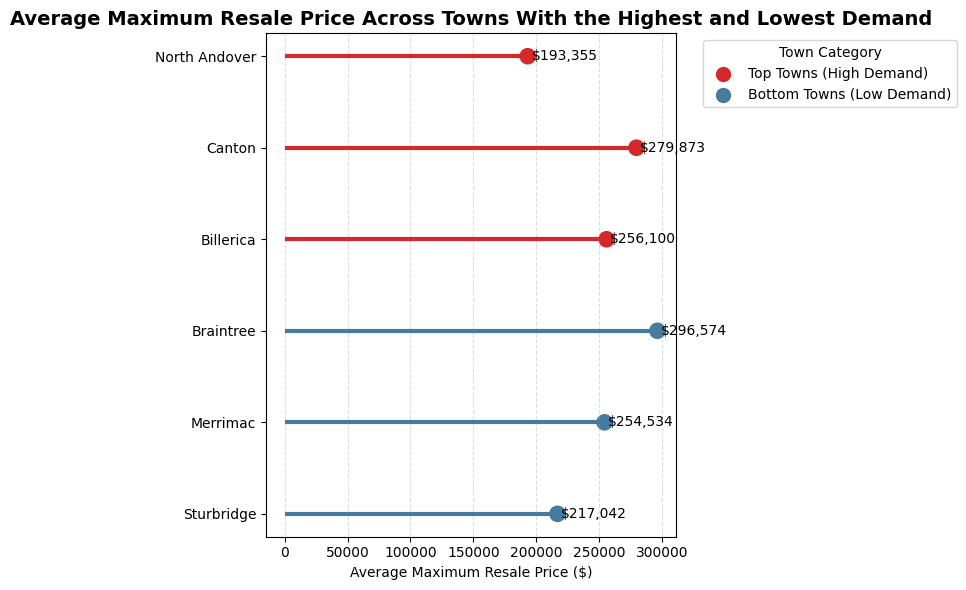

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure numeric price
df['Maximum Resale Price'] = pd.to_numeric(df['Maximum Resale Price'], errors='coerce')

# Average price by town
avg_price = df.groupby('Town', as_index=False)['Maximum Resale Price'].mean()

# Add focus towns
key_towns = ['Medway', 'North Andover', 'Canton', 'Billerica',
             'Braintree', 'Merrimac', 'Lancaster', 'Sturbridge']
key_data = avg_price[avg_price['Town'].isin(key_towns)]

# Combine and remove duplicates
selected = pd.concat([key_data]).drop_duplicates('Town')

# ✅ Custom reversed order
custom_order = ['Sturbridge', 'Lancaster', 'Merrimac', 'Braintree',
                'Billerica', 'Canton', 'North Andover', 'Medway']

# Apply the custom order
selected['Town'] = pd.Categorical(selected['Town'], categories=custom_order, ordered=True)
selected = selected.sort_values('Town')

# ✅ Color rule: first 3 = blue (bottom 3 demand), rest = red (top 3 demand)
selected['color'] = ['#457b9d' if i < 3 else '#d62828' for i in range(len(selected))]

# Plot (Lollipop chart)
plt.figure(figsize=(10,6))
plt.hlines(y=selected['Town'], xmin=0, xmax=selected['Maximum Resale Price'],
           color=selected['color'], linewidth=3)
plt.scatter(selected['Maximum Resale Price'], selected['Town'],
            color=selected['color'], s=120)

# Labels
for i, (town, price) in enumerate(zip(selected['Town'], selected['Maximum Resale Price'])):
    plt.text(price + 3000, town, f"${price:,.0f}", va='center', fontsize=10)

# Title & labels
plt.title("Average Maximum Resale Price Across Towns With the Highest and Lowest Demand",
          fontsize=14, fontweight='bold')
plt.xlabel("Average Maximum Resale Price ($)")
plt.ylabel("")

# ✅ Legend (moved outside the plot)
plt.scatter([], [], color='#d62828', label='Top Towns (High Demand)', s=100)
plt.scatter([], [], color='#457b9d', label='Bottom Towns (Low Demand)', s=100)
plt.legend(title="Town Category", bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)

# Style
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust layout to make space for legend
plt.show()
